In [2]:
import pandas as pd
df= pd.read_csv("train.csv")
df.shape




(1460, 81)

In [3]:
df.isnull().sum()[df.isnull().sum() > 0]
df['HeatingQC'].value_counts()


HeatingQC
Ex    741
TA    428
Gd    241
Fa     49
Po      1
Name: count, dtype: int64

In [4]:
df.columns.tolist()

['Id',
 'MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF'

In [5]:
# DROPPED COLUMNS AND REASONS
dropped = {
    'PoolQC': 'only 3 houses have pool, not enough data',
    'RoofMatl': '99% same value, no variation',
    'GarageCond': 'redundant with GarageQual, lower variation',
    'Alley': 'only 91 houses have alley access, not enough data',
    'Utilities': '99% same value, no variation',
    'Heating': '99% same value, no variation',
    'LowQualFinSF': 'limited data availability',
    'PoolArea': 'limited data availability',
    'MiscFeature': 'lot of missing values ',
    'MiscVal': 'limited data availability',
    'LandSlope': '99% same value, no variation',
    'BsmtHalfBath': 'limited data availability',
    'BsmtFinSF2': 'limited data availability',
    'BsmtFinType2': '99% same value, no variation',
    'BsmtUnfSF': 'limited data availability',
    'KitchenAbvGr': '99% same value, no variation',
    'GarageCond': 'redundant with GarageQual, lower variation',
    'MoSold': ' it do not affect the price of the house',
    'YrSold': ' it do not affect the price of the house',
    'OpenPorchSF': 'combined with other porch features to create TotalPorchSF',
    'EnclosedPorch': 'combined with other porch features to create TotalPorchSF',
    '3SsnPorch': 'combined with other porch features to create TotalPorchSF',
    'ScreenPorch': 'combined with other porch features to create TotalPorchSF',
    'BsmtFinSF1':'already have total basement sf',
    'BsmtFinSF2': 'already have total basement sf',
    'BsmtUnfSF': 'already have total basement sf',
    'OverallCond': ' less impact on price compared to OverallQuall, corr in negative',
    
    
}


    # add every column you drop here


In [6]:
df['Street'].value_counts()


Street
Pave    1454
Grvl       6
Name: count, dtype: int64

In [7]:
# Create combined columns first
df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']
df.shape


(1460, 82)

In [8]:
df.shape

(1460, 82)

In [9]:
df = df.drop(columns=list(dropped.keys()), errors='ignore')
df.shape

(1460, 58)

In [10]:
print(df['OverallQual'].value_counts().sort_index())


OverallQual
1       2
2       3
3      20
4     116
5     397
6     374
7     319
8     168
9      43
10     18
Name: count, dtype: int64


In [11]:
print(df['OverallQual'].corr(df['SalePrice']))


0.7909816005838052


In [12]:
print(df['TotalBsmtSF'].corr(df['SalePrice']))

0.6135805515591954


In [13]:
df['LotArea'].value_counts()
df['LotArea'].isnull().sum()

np.int64(0)

In [14]:
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
print(corr.to_string())

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
LotFrontage     0.351799
WoodDeckSF      0.324413
2ndFlrSF        0.319334
HalfBath        0.284108
LotArea         0.263843
BsmtFullBath    0.227122
TotalPorchSF    0.195739
BedroomAbvGr    0.168213
Id             -0.021917
MSSubClass     -0.084284


In [15]:
df['MSSubClass'].dtype

dtype('int64')

In [16]:
df.groupby('MSSubClass')['SalePrice'].mean().sort_values(ascending=False)


MSSubClass
60     239948.501672
120    200779.080460
75     192437.500000
20     185224.811567
80     169736.551724
70     166772.416667
40     156125.000000
85     147810.000000
50     143302.972222
160    138647.380952
90     133541.076923
190    129613.333333
45     108591.666667
180    102300.000000
30      95829.724638
Name: SalePrice, dtype: float64

In [17]:
df['MSSubClass'] = df['MSSubClass'].astype(str)

MISSING VALUES HANDELLING

REASONS:
1) Electrical:- using mode since it is a categorical feature and the missing proportion is negligible.
2) MasVnrType:- filled missing values with `None` where masonry veneer was absent (`MasVnrArea = 0`), while inconsistent rows with existing veneer area were filled using mode.
3) MasVnrArea:- filled missing values with `0.0` for houses without masonry veneer.
4) FireplaceQu:- filled missing values with `NoFireplace` since missing values indicated absence of fireplace.
5) LotFrontage :- filled with median frontage of same neighbourhood. Houses in same area have similar lot sizes. Smarter than global median.
6) Garage Features (GarageType, GarageYrBlt, GarageFinish, GarageQual):- missing values represented houses without garages, so categorical features were filled with `NoGarage` and `GarageYrBlt` with `0`.
7) Basement Features (BsmtQual, BsmtFinType1, BsmtCond):- missing values represented houses without basements, therefore filled with `NoBasement`.
8) BsmtExposure:- one inconsistent missing value where basement existed was filled with `No`, while remaining missing values were filled with `NoBasement`.

In [18]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values)


Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
BsmtExposure      38
BsmtQual          37
BsmtFinType1      37
BsmtCond          37
MasVnrArea         8
Electrical         1
dtype: int64


In [19]:
df['Fence'].value_counts()


Fence
MnPrv    157
GdPrv     59
GdWo      54
MnWw      11
Name: count, dtype: int64

In [20]:
df['Electrical'].value_counts()
df['Electrical'].dtype


df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [21]:
[col for col in df.columns if "Garage" in col]


['GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual']

In [22]:
df[df["GarageType"].isnull()][
    ["GarageType", "GarageArea", "GarageCars", "GarageQual", "GarageFinish", "GarageYrBlt"]
] 

,GarageType,GarageArea,GarageCars,GarageQual,GarageFinish,GarageYrBlt
39,NaN,0,0,NaN,NaN,NaN
48,NaN,0,0,NaN,NaN,NaN
78,NaN,0,0,NaN,NaN,NaN
88,NaN,0,0,NaN,NaN,NaN
89,NaN,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...
1349,NaN,0,0,NaN,NaN,NaN
1407,NaN,0,0,NaN,NaN,NaN
1449,NaN,0,0,NaN,NaN,NaN
1450,NaN,0,0,NaN,NaN,NaN


In [23]:
# Filling garage-related missing values

garage_cols = ["GarageType", "GarageFinish", "GarageQual"]

for col in garage_cols:
    df[col] = df[col].fillna("NA")

df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

In [24]:
df['GarageType'].value_counts()

GarageType
Attchd     870
Detchd     387
BuiltIn     88
NA          81
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64

In [25]:
df[df["BsmtExposure"].isnull()][
    ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "TotalBsmtSF"]
]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,TotalBsmtSF
17,NaN,NaN,NaN,NaN,0
39,NaN,NaN,NaN,NaN,0
90,NaN,NaN,NaN,NaN,0
102,NaN,NaN,NaN,NaN,0
156,NaN,NaN,NaN,NaN,0
182,NaN,NaN,NaN,NaN,0
259,NaN,NaN,NaN,NaN,0
342,NaN,NaN,NaN,NaN,0
362,NaN,NaN,NaN,NaN,0
371,NaN,NaN,NaN,NaN,0


In [26]:
df['BsmtExposure'].value_counts()
df['BsmtQual'].value_counts()
pd.crosstab(df["BsmtQual"], df["BsmtCond"])
df.groupby("BsmtQual")["SalePrice"].mean()
df.groupby("BsmtCond")["SalePrice"].mean()


BsmtCond
Fa    121809.533333
Gd    213599.907692
Po     64000.000000
TA    183632.620900
Name: SalePrice, dtype: float64

In [27]:
# one special case where there was basement but no exposure
df.loc[948, "BsmtExposure"] = "No"

In [28]:
# Filling basement-related missing values

bsmt_cols = ["BsmtQual", "BsmtCond", "BsmtFinType1", "BsmtExposure"]

for col in bsmt_cols:
    df[col] = df[col].fillna("NA")



In [29]:
print(df[df['FireplaceQu'].isnull()]['Fireplaces'].value_counts())

Fireplaces
0    690
Name: count, dtype: int64


In [30]:
df['FireplaceQu']= df['FireplaceQu'].fillna("NA")

In [31]:
df['Fence']= df['Fence'].fillna("NA")

In [32]:
print(df[df['MasVnrType'].isnull()]['MasVnrArea'].value_counts())

MasVnrArea
0.0      859
1.0        2
288.0      1
344.0      1
312.0      1
Name: count, dtype: int64


In [33]:
df[df["MasVnrType"].isnull()][
    ["MasVnrType", "MasVnrArea"]
]

,MasVnrType,MasVnrArea
1,NaN,0.0
3,NaN,0.0
5,NaN,0.0
8,NaN,0.0
9,NaN,0.0
...,...,...
1454,NaN,0.0
1455,NaN,0.0
1457,NaN,0.0
1458,NaN,0.0


In [34]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [35]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

In [36]:
df['MasVnrType'].value_counts()

MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [37]:
mode_value = df["MasVnrType"].mode()[0]

df.loc[[624, 1300, 1334], "MasVnrType"] = mode_value

In [38]:
# Filling remaining missing masonry veneer values

df["MasVnrType"] = df["MasVnrType"].fillna("None")
df["MasVnrArea"] = df["MasVnrArea"].fillna(0.0)

In [39]:
df['LotFrontage'].value_counts()

LotFrontage
60.0     143
70.0      70
80.0      69
50.0      57
75.0      53
        ... 
138.0      1
160.0      1
152.0      1
153.0      1
46.0       1
Name: count, Length: 110, dtype: int64

In [40]:
pd.set_option('display.max_rows', None)

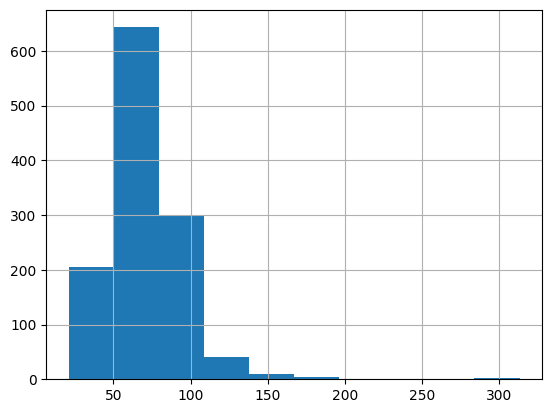

In [41]:
# lets check whether to mean or median for lot frontage
import matplotlib.pyplot as plt
df['LotFrontage'].hist()
plt.show()

In [42]:
#  above 1 means highly skewed, so we will use median to fill the missing values
print(df['LotFrontage'].skew())

2.163569142324884


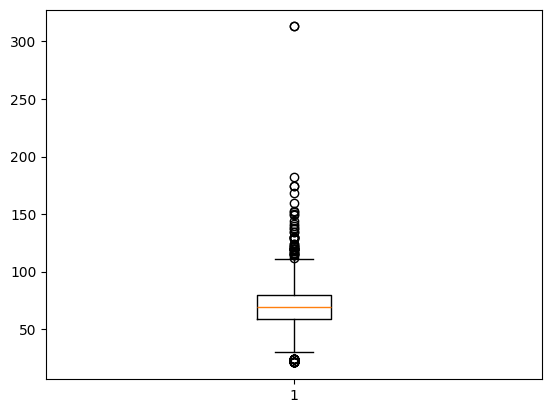

In [43]:

plt.boxplot(df["LotFrontage"].dropna())
plt.show()

In [44]:
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

In [45]:
df.isnull().sum().sum()

np.int64(0)

    ONE HOT ENCODING

In [46]:
list(df.select_dtypes(include="object").columns)

C:\Users\kashi\AppData\Local\Temp\ipykernel_12696\603170240.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  list(df.select_dtypes(include="object").columns)


['MSSubClass',
 'MSZoning',
 'Street',
 'LotShape',
 'LandContour',
 'LotConfig',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'PavedDrive',
 'Fence',
 'SaleType',
 'SaleCondition']

In [47]:
df = pd.get_dummies(df)
print(df.shape)

(1460, 260)


In [48]:
from sklearn.model_selection import train_test_split

X=df.drop(columns=['SalePrice']) # This is DATA
y=df['SalePrice'] # This is TARGET

In [49]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.25, random_state=42)



In [50]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1095, 259)
X_test: (365, 259)
y_train: (1095,)
y_test: (365,)


In [51]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred= model.predict(X_test)

rmse=np.sqrt(mean_squared_error(y_test, y_pred))
r2= r2_score(y_test, y_pred)


print(f"RMSE: {rmse:,.0f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 31,237
R2 Score: 0.8607


In [53]:
model.score(X_train, y_train)


0.9030809885460374

In [54]:
model.score(X_test, y_test)

0.8607168551404278

In [55]:
df["SalePrice"].mean()

np.float64(180921.19589041095)

In [56]:
df["SalePrice"].median()

np.float64(163000.0)

In [57]:
df["SalePrice"].min(), df["SalePrice"].max()

(np.int64(34900), np.int64(755000))

In [58]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

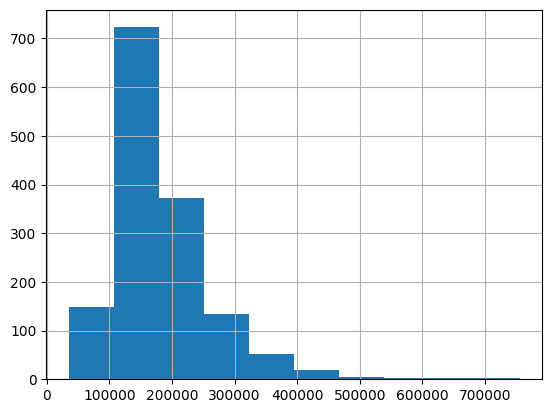

In [59]:
df["SalePrice"].hist()
plt.show()

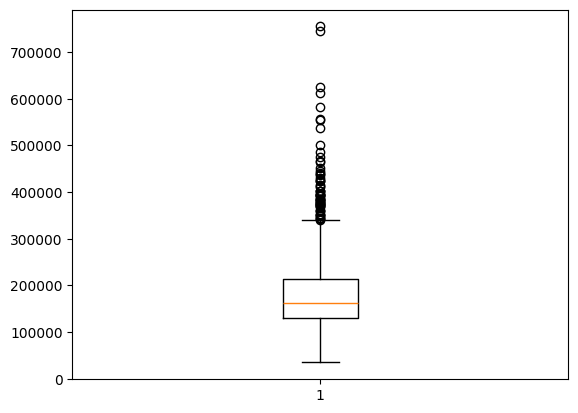

In [60]:
plt.boxplot(df["SalePrice"])
plt.show()

In [61]:
print((df['SalePrice'] > 350000).sum())

54


In [62]:
df = df[df['SalePrice'] <= 350000]
print(df.shape)

(1406, 260)


In [63]:
X=df.drop(columns=['SalePrice']) # This is DATA
y=df['SalePrice'] # This is TARGET

In [ ]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.25, random_state=42)



In [65]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1054, 259)
X_test: (352, 259)
y_train: (1054,)
y_test: (352,)


In [66]:
model= LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [67]:
y_pred= model.predict(X_test)

rmse=np.sqrt(mean_squared_error(y_test, y_pred))
r2= r2_score(y_test, y_pred)


print(f"RMSE: {rmse:,.0f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 21,607
R2 Score: 0.8592


In [69]:
df["SalePrice"].mean()

np.float64(171111.9374110953)

In [70]:
df["SalePrice"].median()

np.float64(159975.0)

In [71]:
df["SalePrice"].skew()

np.float64(0.7185796070282274)